In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera

# Ações do Itaú Unibanco (ITUB4)

Este notebook tem como objetivo avaliar a consistência e a qualidade dos dados referentes aos preços de ações do Itaú Unibanco que o Yahoo Finance disponibiliza através da sua própria biblioteca `yfinance`.

In [2]:
# Pegando 10 anos de histórico de preços de ações do ITUB4
dados = yf.download(tickers="ITUB4.SA", start="2016-01-01", end="2026-01-01", 
                    auto_adjust=False, multi_level_index=False)

dados

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2016-01-04,7.312710,13.442456,13.955976,13.442456,13.865040,43135315
2016-01-05,7.373818,13.554788,13.790152,13.415710,13.586883,23898487
2016-01-06,7.344720,13.501297,13.816898,13.265933,13.372917,37978811
2016-01-07,7.205036,13.244537,13.528043,13.244537,13.319425,32592365
2016-01-08,7.207950,13.249886,13.506646,13.249886,13.346171,20493097
...,...,...,...,...,...,...
2025-12-22,38.044254,38.456310,38.563107,38.145630,38.320389,15858704
2025-12-23,38.668564,39.087379,39.174755,38.582523,38.640778,10490138
2025-12-26,38.681038,39.099998,39.220001,38.709999,39.020000,12196300


## Significado das variáveis 

- **Adj Close**: preço de fechamento após o ajuste para todos os dividendos e desdobramentos aplicáveis;
- **Close**: último preço negociado antes da bolsa fechar;
- **High**: preço máximo que a ação atingiu durante aquele dia;
- **Low**: preço mínimo que a ação atingiu durante aquele dia;
- **Open**: primeiro preço negociado quando a bolsa abriu naquele dia;
- **Volume**: quantidade total de ações negociadas naquele dia.

## Análise exploratória dos dados 

In [3]:
# Vendo informações dos dados 
dados.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2491 entries, 2016-01-04 to 2025-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2491 non-null   float64
 1   Close      2491 non-null   float64
 2   High       2491 non-null   float64
 3   Low        2491 non-null   float64
 4   Open       2491 non-null   float64
 5   Volume     2491 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 136.2 KB


In [4]:
# Verificando quantidade de valores faltantes dos dados 
dados.isnull().sum().sum()

np.int64(0)

In [ ]:
# Pegando URL da ANBIMA para o arquivo oficial de feriados 
url_anbima = "https://www.anbima.com.br/feriados/arqs/feriados_nacionais.xls"

# Lendo arquivo de feriados 
df_feriados = pd.read_excel(url_anbima, skipfooter=9)

# Convertendo coluna de datas da ANBIMA para o formato datetime
df_feriados['Data'] = pd.to_datetime(df_feriados['Data'])

# Filtrndo feriados que estão dentro no período dos dados 
feriados_periodo = df_feriados[(df_feriados['Data'] >= dados.index.min()) & (df_feriados['Data'] <= dados.index.max())]

# Verificando se feriados estão nos dados fornecidos pelo Yahoo Finance
feriados_no_dataset = dados.index.intersection(feriados_periodo['Data'])

# Confirmando se o Yahoo Finance realmente excluiu os feriados 
feriados_excluidos = feriados_periodo[~feriados_periodo['Data'].isin(dados.index)]

print(f"Total de feriados oficiais da ANBIMA no período: {len(feriados_periodo)}")
print(f"Feriados que o Yahoo Finance pulou corretamente: {len(feriados_excluidos)}")
print(f"Feriados que vazaram para o dataset (deveria ser 0): {len(feriados_no_dataset)}")

Total de feriados oficiais da ANBIMA no período: 121
Feriados que o Yahoo Finance pulou corretamente: 115
Feriados que vazaram para o dataset (deveria ser 0): 6


In [6]:
# Verificando se realmente há feriados vazados 
dados[dados.index.isin(feriados_no_dataset)]

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2017-06-15,12.620716,21.423948,21.423948,21.423948,21.423948,0
2017-09-07,14.754139,24.766108,24.766108,24.766108,24.766108,0
2017-10-12,15.779662,26.478374,26.478374,26.478374,26.478374,0
2017-11-02,14.497921,24.318916,24.318916,24.318916,24.318916,0
2017-11-15,14.354095,24.077669,24.077669,24.077669,24.077669,0
2017-12-25,14.976953,25.025007,25.025007,25.025007,25.025007,0


In [7]:
# Verificado se existem outras dias com volume zerado
dados[dados['Volume'] == 0]

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2017-05-29,12.473329,21.182699,21.182699,21.182699,21.182699,0
2017-06-15,12.620716,21.423948,21.423948,21.423948,21.423948,0
2017-09-07,14.754139,24.766108,24.766108,24.766108,24.766108,0
2017-10-12,15.779662,26.478374,26.478374,26.478374,26.478374,0
2017-11-02,14.497921,24.318916,24.318916,24.318916,24.318916,0
2017-11-06,14.701372,24.660194,24.660194,24.660194,24.660194,0
2017-11-15,14.354095,24.077669,24.077669,24.077669,24.077669,0
2017-11-20,14.918856,25.025007,25.025007,25.025007,25.025007,0
2017-12-25,14.976953,25.025007,25.025007,25.025007,25.025007,0


In [ ]:
# Removendo do dataset os dias em que o volume foi zero 
dados_limpos = dados[dados['Volume'] > 0].copy()

# Verificando se os os feriados vazados sumiram
feriados_restantes = dados_limpos.index.intersection(feriados_periodo['Data'])

print(f"Feriados vazados após a limpeza: {len(feriados_restantes)}")

Feriados vazados após a limpeza: 0


Durante a etapa de pré-processamento, foram identificadas observações com volume negociado igual a zero, correspondentes a datas sem negociação efetiva na B3, como feriados e outros dias de fechamento do mercado. Nessas datas, a base do Yahoo Finance mantém registros com preços repetidos do último pregão, produzindo retornos artificiais iguais a zero. Para evitar distorções nas estimativas de volatilidade e na modelagem dos regimes de mercado, essas observações foram removidas antes do cálculo dos log-retornos.

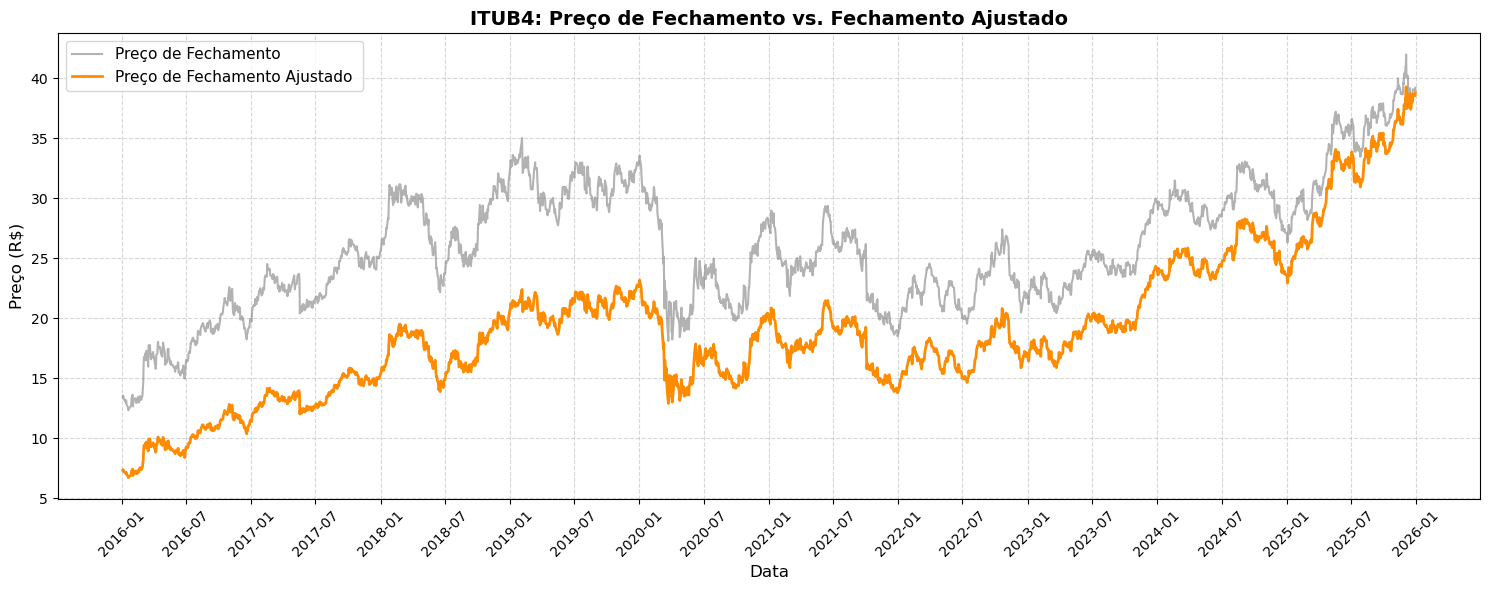

In [9]:
plt.figure(figsize=(15, 6))

# Plotando evolução dos preços de fechamento para comparação 
plt.plot(dados_limpos.index, dados_limpos['Close'], label='Preço de Fechamento', color='gray', alpha=0.6)
plt.plot(dados_limpos.index, dados_limpos['Adj Close'], label='Preço de Fechamento Ajustado ', color='darkorange', linewidth=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6)) 
plt.xticks(rotation=45)

plt.title("ITUB4: Preço de Fechamento vs. Fechamento Ajustado", fontsize=14, fontweight='bold')
plt.xlabel("Data", fontsize=12)
plt.ylabel("Preço (R$)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

O gráfico comparativo evidencia o impacto cumulativo dos eventos corporativos, especialmente da distribuição de dividendos e juros sobre capital próprio, sobre a série temporal das ações do ITUB4 ao longo do período analisado. Enquanto a linha cinza representa o preço de fechamento observado no mercado ao final de cada pregão, a linha laranja corresponde ao preço de fechamento ajustado, que incorpora retrospectivamente os efeitos de proventos e demais eventos societários, preservando a comparabilidade histórica da série.

Sob a perspectiva da modelagem estatística por meio de Modelos Ocultos de Markov (HMM), a utilização da série ajustada é fundamental, pois reduz a ocorrência de variações artificiais decorrentes de eventos corporativos. Nas datas de corte de dividendos e juros sobre capital próprio, o preço da ação sofre um ajuste mecânico que não está associado a mudanças nas condições econômicas ou no risco do ativo. Ao utilizar os preços ajustados, evita-se que essas variações sejam interpretadas pelo modelo como choques de mercado ou mudanças de regime de volatilidade, permitindo que os estados identificados reflitam mais adequadamente a dinâmica real dos retornos.

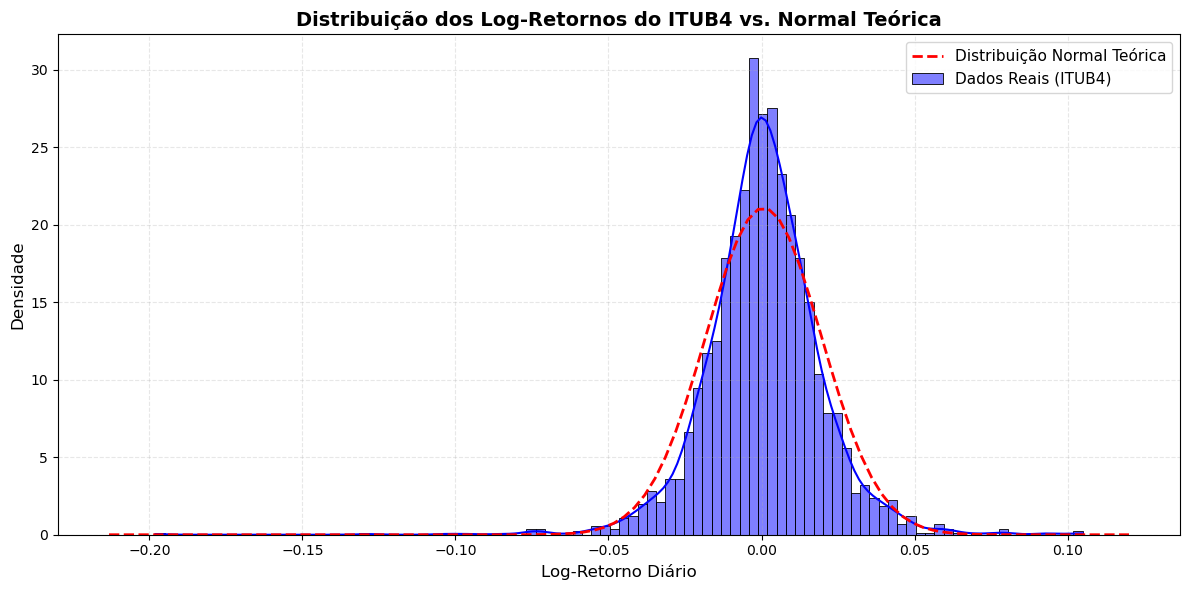

In [10]:
# Calculando logaritmo dos retornos na base limpa
dados_limpos['Log Ret'] = np.log(dados_limpos['Adj Close'] / dados_limpos['Adj Close'].shift(1))

# Excluindo a primeira data do histórico que ficou como NaN
retornos = dados_limpos['Log Ret'].dropna()

plt.figure(figsize=(12, 6))

# Plotando histograma real dos dados
sns.histplot(retornos, kde=True, bins=100, color='blue', stat='density', label='Dados Reais (ITUB4)')

# Plotando distribuição normal teórica para comparação
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, retornos.mean(), retornos.std())
plt.plot(x, p, 'r--', linewidth=2, label='Distribuição Normal Teórica')

plt.title("Distribuição dos Log-Retornos do ITUB4 vs. Normal Teórica", fontsize=14, fontweight='bold')
plt.xlabel("Log-Retorno Diário", fontsize=12)
plt.ylabel("Densidade", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Estatísticas básicas
media = retornos.mean()
desvio = retornos.std()
assimetria = retornos.skew()
curtose = retornos.kurtosis()  

# Teste de Jarque-Bera
jb_stat, jb_pvalor = jarque_bera(retornos)

print("Análise estatística dos log-retornos")
print(f"Média: {media:.4f}")
print(f"Desvio padrão: {desvio:.4f}")
print(f"Assimetria: {assimetria:.4f}")
print(f"Curtose: {curtose:.4f}")
print(f"Jarque-Bera: {jb_stat:.4f}")
print(f"p-vlor: {jb_pvalor:.4f}")

Análise estatística dos log-retornos
Média: 0.0007
Desvio padrão: 0.0189
Assimetria: -0.5010
Curtose: 8.3334
Jarque-Bera: 7243.6114
p-vlor: 0.0000


O histograma dos log-retornos do ITUB4, comparado a uma distribuição normal teórica, demostra características típicas de séries financeiras. Observa-se uma maior concentração de observações em torno da média e uma frequência mais elevada de eventos extremos nas caudas da distribuição do que aquela prevista pela normal, indicando a presença de **leptocurtose** e **caudas gordas** (*fat tails*). Além disso, a distribuição apresenta indícios de assimetria à esquerda, sugerindo que movimentos negativos extremos tendem a ser mais intensos do que movimentos positivos de magnitude semelhante.

A análise estatística confirma essas observações. O coeficiente de assimetria foi de **-0,501**, indicando assimetria negativa moderada, enquanto a curtose atingiu **8,333**, confirmando a forte leptocurtose. Adicionalmente, o teste de Jarque-Bera resultou em uma estatística de **7243,70** com **p-valor zerado**, levando à rejeição da hipótese de normalidade. Em conjunto, esses resultados mostram que os log-retornos do ITUB4 não são adequadamente descritos por uma única distribuição normal, justificando a utilização de modelos mais flexíveis, como os Modelos Ocultos de Markov (HMM), para capturar diferentes regimes de volatilidade ao longo do tempo.

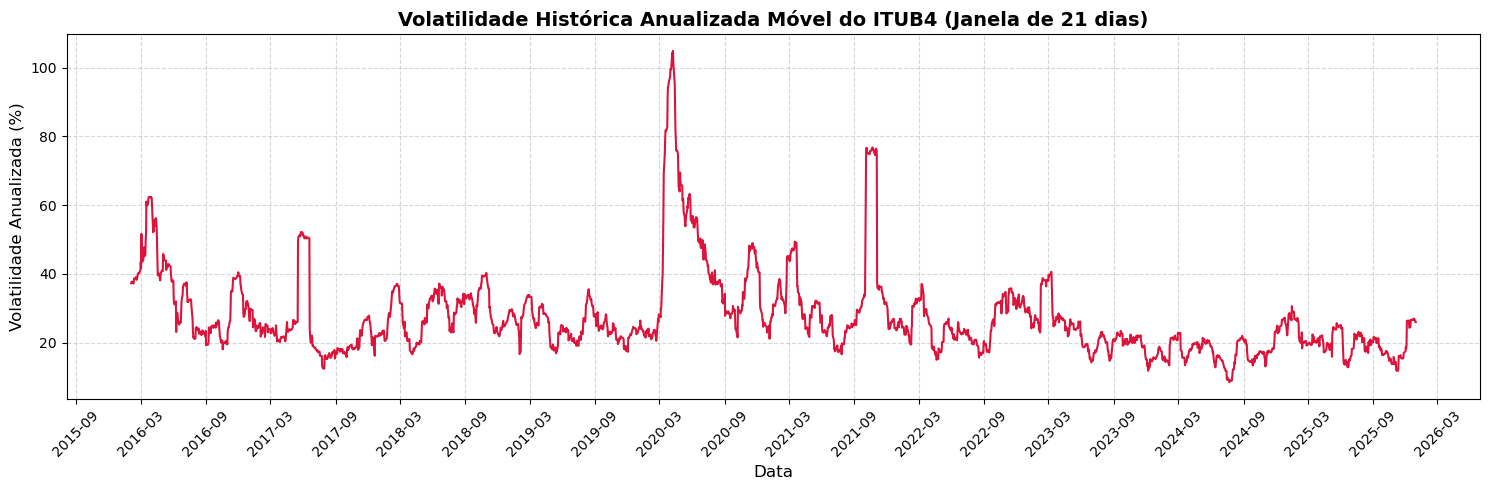

In [12]:
# Calculando volatilidade anualizada móvel com janela de 21 dias úteis 
dados_limpos['Volatility'] = retornos.rolling(window=21).std() * np.sqrt(252) 

# Muultiplicando por 100 para estar em porcentagem 
dados_limpos['Volatility %'] = dados_limpos['Volatility'] * 100

plt.figure(figsize=(15, 5))
plt.plot(dados_limpos.index, dados_limpos['Volatility %'], color='crimson', linewidth=1.5)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.title("Volatilidade Histórica Anualizada Móvel do ITUB4 (Janela de 21 dias)", fontsize=14, fontweight='bold')
plt.xlabel("Data", fontsize=12)
plt.ylabel("Volatilidade Anualizada (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

O gráfico da volatilidade histórica anualizada móvel do ITUB4 destaca o comportamento dinâmico e não constante do risco ao longo do período analisado, destacando o fenômeno conhecido como agrupamento de volatilidade (volatility clustering). Observa-se a presença de longos períodos em que a volatilidade permanece relativamente estável, geralmente em torno de 20% ao ano, intercalados por episódios de forte turbulência nos quais o risco aumenta substancialmente. O caso mais expressivo ocorre no primeiro trimestre de 2020, quando a volatilidade supera 100% ao ano em decorrência dos impactos iniciais da pandemia de Covid-19. Outros períodos de elevada instabilidade também podem ser observados, como os picos registrados ao longo de 2021.

Esse comportamento revela que a volatilidade não se mantém constante ao longo do tempo e tende a se agrupar em períodos de maior ou menor intensidade. A alternância entre fases relativamente estáveis e períodos de elevada turbulência sugere a possibilidade de diferentes regimes de mercado, tornando apropriada a utilização de Modelos Ocultos de Markov (HMM) para modelar a dinâmica dos retornos. Esses modelos permitem representar a série como uma sucessão de estados latentes associados a diferentes níveis de volatilidade, oferecendo uma estrutura adequada para investigar mudanças no comportamento do mercado ao longo do tempo.